<a href="https://colab.research.google.com/github/madan-genai/Self-RAG-Concepts/blob/main/self_RAG_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langchain_community langchain_google_genai langchain_core langchain_text_splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
!pip install sentence_transformers

In [4]:
!pip install PyPDF faiss_cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 64.8 MB/s eta 0:00:00


In [5]:
!pip install langchain_huggingface

In [6]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

/tmp/ipykernel_411/2284545284.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


False

In [7]:
docs = (
    PyPDFLoader("/content/Company_Policies.pdf").load()
    + PyPDFLoader("/content/Company_Profile.pdf").load()
    + PyPDFLoader("/content/Product_and_Pricing.pdf").load()
)

In [8]:
import os
os.environ["GEMINI_API_KEY"] = ""

In [9]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [10]:
chunks = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=150).split_documents(docs)

In [11]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k":3})

In [13]:
class State(TypedDict):
  answer:str
  needs_retrieval:bool
  question:str
  docs:List[Document]
  relevant_docs:List[Document]

In [14]:
class RetrieveDecision(BaseModel):
  should_retrieve : bool = Field(..., description=("True if external documents are needed to answer the question reliably , else False"))

In [15]:
decide_retrieval_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."),
        ("human", "Questiion:{Question}"),
    ]
)

In [16]:
should_retrieve_llm=llm.with_structured_output(RetrieveDecision)

In [17]:
def retrieve(state:"State"):
  Decision:RetrieveDecision = should_retrieve_llm.invoke(
      decide_retrieval_prompt.format_messages(Question=state["question"])
  )
  return {"needs_retrieval":Decision.should_retrieve}

In [18]:
direct_prompt_generation = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def direct_answer(state:"State"):
  answer = llm.invoke(direct_prompt_generation.format_messages(question=state["question"]))
  return {"answer": answer.content}

In [19]:
def retrieve(state:"State"):
  return {"docs":retriever.invoke(state["question"])}

In [20]:
class RelevanceDecision(BaseModel):
  is_relevant: bool = Field(..., description=("True if the document helps answer the question, else False."))

is_relevant_prompt = ChatPromptTemplate(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state:"State"):
  relevant_docs = []
  for doc in state["docs"]:
    Decision:RelevanceDecision = relevance_llm.invoke(
        is_relevant_prompt.format_messages(
            question=state["question"],
            document = doc.page_content
        )
    )
    if Decision.is_relevant:
      relevant_docs.append(doc)
  return {"relevant_docs": relevant_docs}

In [21]:
def decision_after_route(state:"State") -> Literal["direct_answer","retrieve"]:
  if state["needs_retrieval"]:
    return "retrieve"
  else:
    return "direct_answer"

In [22]:
retrieval_answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an AI assistant. Answer the user's question based on the provided documents. "
            "If the documents do not contain enough information, state that you cannot answer from the provided context.\n\n"
            "Documents:\n{documents}"
        ),
        ("human", "{question}"),
    ]
)

In [23]:
def answer_with_retrieval(state:"State"):
  docs_content = "\n\n".join([doc.page_content for doc in state["relevant_docs"]])
  answer = llm.invoke(retrieval_answer_prompt.format_messages(question=state["question"], documents=docs_content))
  return {"answer": answer.content}

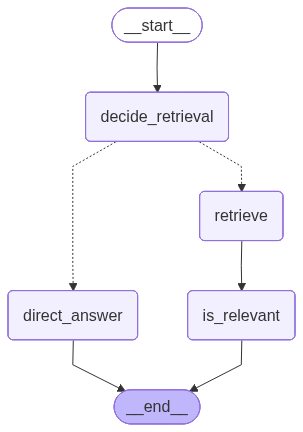

In [24]:
g = StateGraph(State)
g.add_node("decide_retrieval",retrieve)
g.add_node("direct_answer",direct_answer)
g.add_node("is_relevant",is_relevant)
g.add_node("retrieve",retrieve)

g.add_edge(START, "decide_retrieval")
g.add_conditional_edges(
    "decide_retrieval",
    decision_after_route,
    {
        "direct_answer": "direct_answer",
        "retrieve":"retrieve",
    }
)
g.add_edge("direct_answer",END)
g.add_edge("retrieve","is_relevant")
g.add_edge("is_relevant",END)

app = g.compile()
app

In [25]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
        "needs_retrieval": True,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

In [26]:
result['needs_retrieval']

True

In [27]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision
****************************************************************************************************
Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Fo

In [28]:
for doc in result['docs']:
    print(doc.page_content)
    print("*"*100)

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision
****************************************************************************************************
Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Fo